In [1]:
import time
start_time=time.time()

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
from lmfit.model import save_modelresult
import math

# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

/Users/javier/miniconda3/envs/viento/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
from pipeline_config import MAPS_DIR

In [4]:
data_all = [
    'MUSE-M42-H-bin0',
    'MUSE-M42-N-bin0',
    'MUSE-M42-O-bin0',
    'MUSE-M42-S-bin0',
    'MUSE-M42-Ar-bin0',
]


# Custom labels dictionary
labels_dict = {
    'MUSE-M42-H-bin0': r'H$\alpha$',
    'MUSE-M42-N-bin0': r'[O III] $\lambda$5007',
    'MUSE-M42-O-bin0': r'[N II] $\lambda$6583',
    'MUSE-M42-S-bin0': r'[S III] $\lambda$9069',
    'MUSE-M42-Ar-bin0': r'[Ar III] $\lambda$7136',

}

In [5]:
processed_data = {}
raw_data = {}

for name in data_all:
    fits_path = MAPS_DIR / f"{name}.fits"

    with fits.open(fits_path) as hdul:
        sb = hdul['MOM0'].data.astype(float)
        vv = hdul['MOM1'].data.astype(float)
        mask = hdul['MASK'].data.astype(bool)

    # Apply mask: invalid pixels -> NaN
    sb[~mask] = np.nan
    vv[~mask] = np.nan

    # If you still want to treat zero surface brightness as invalid
    vv[sb == 0] = np.nan

    raw_data[name] = {
        "sb": sb,
        "vv": vv,
        "mask": mask
    }

    # Create DataFrames
    sb_df = (
        pd.DataFrame(sb)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'X', 'level_1': 'Y', 0: 'SB'})
    )

    vv_df = (
        pd.DataFrame(vv)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'X', 'level_1': 'Y', 0: 'VV'})
    )

    # Merge into one DataFrame
    df = vv_df.copy()
    df['SB'] = sb_df['SB']

    processed_data[name] = df

In [6]:
processed_data[data_all[0]].describe()

,X,Y,VV,SB
count,2.606616e+06,2.606616e+06,2.188334e+06,2.188334e+06
mean,7.375000e+02,8.825000e+02,1.385425e+01,8.167201e-02
std,4.260845e+02,5.098003e+02,2.832606e+00,6.086291e-02
min,0.000000e+00,0.000000e+00,5.001098e+00,2.500001e-02
25%,3.687500e+02,4.410000e+02,1.198946e+01,3.703126e-02
50%,7.375000e+02,8.825000e+02,1.377403e+01,5.555939e-02
75%,1.106250e+03,1.324000e+03,1.569407e+01,1.120541e-01
max,1.475000e+03,1.765000e+03,2.798815e+01,8.909046e-01


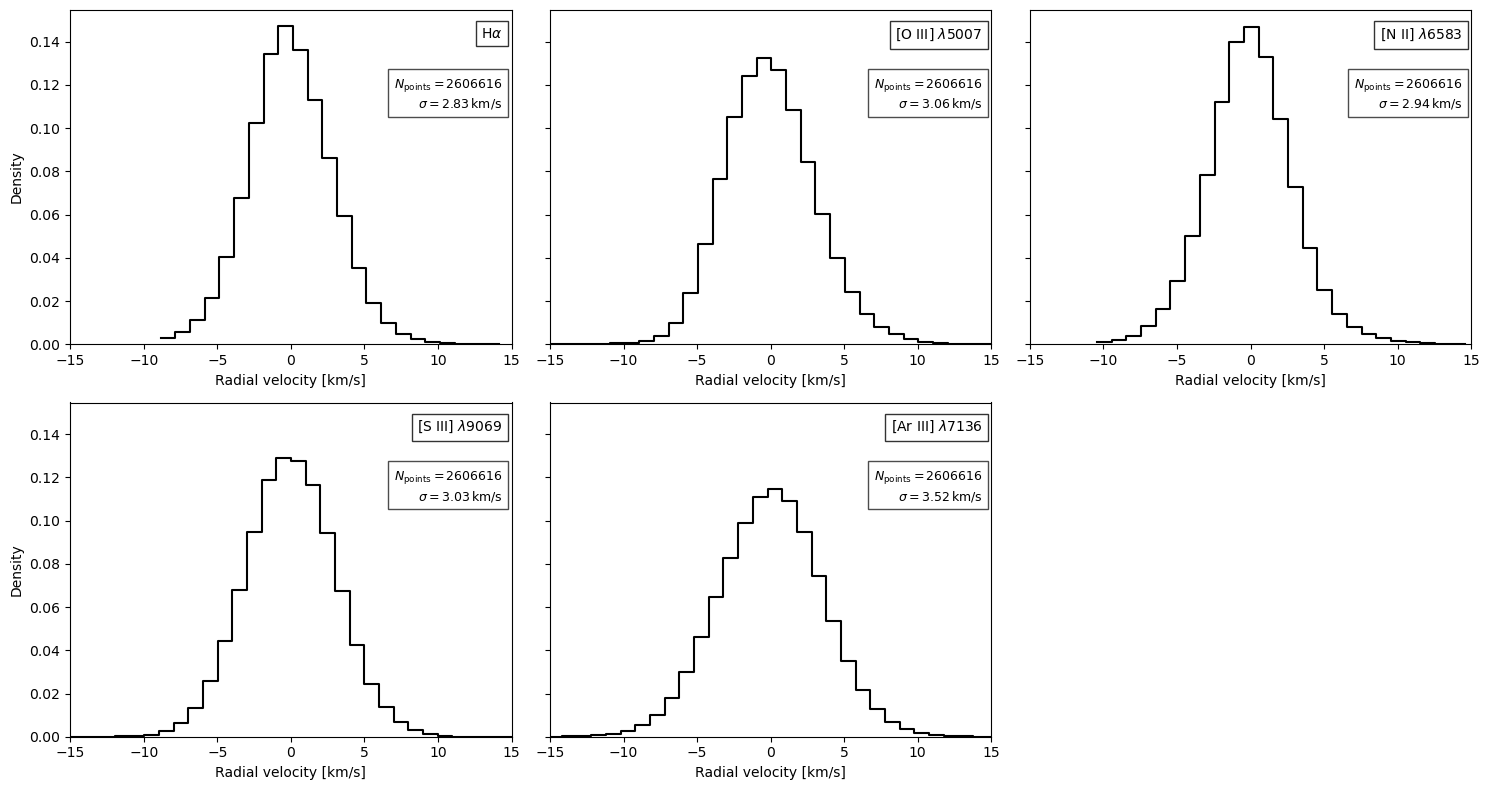

In [7]:
# Layout calculation
n_plots = len(data_all)
n_cols = 3  # Change for a wider grid
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

# Loop through datasets
for ax, name in zip(axes, data_all):
    df = processed_data[name].copy()
    df['RV_centered'] = df['VV'] - df['VV'].mean()

    sns.histplot(
        data=df,
        x="RV_centered",
        binwidth=1,
        element="step",
        fill=False,
        color='k',
        stat='density',
        ax=ax
    )

    # Pretty label and stats
    label = labels_dict.get(name, name)
    ax.text(0.98, 0.95, label, transform=ax.transAxes,
            ha='right', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='k'))

    n_points = len(df)
    var_rv = df['RV_centered'].std()
    stats_text = f"$N_{{\\text{{points}}}} = {n_points}$\n$\\sigma = {var_rv:.2f}\\,\\mathrm{{km/s}}$"
    ax.text(0.98, 0.80, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
    ax.set_xlim(-15,15)
    ax.set_xlabel("Radial velocity [km/s]")

# Remove unused axes if any
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.savefig("Imgs/pdfs_all.pdf", bbox_inches='tight')
plt.show()

/var/folders/1s/7p4dmrfd0d7d8t0h6trn9dhw0000gr/T/ipykernel_35512/3231697480.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for cbar


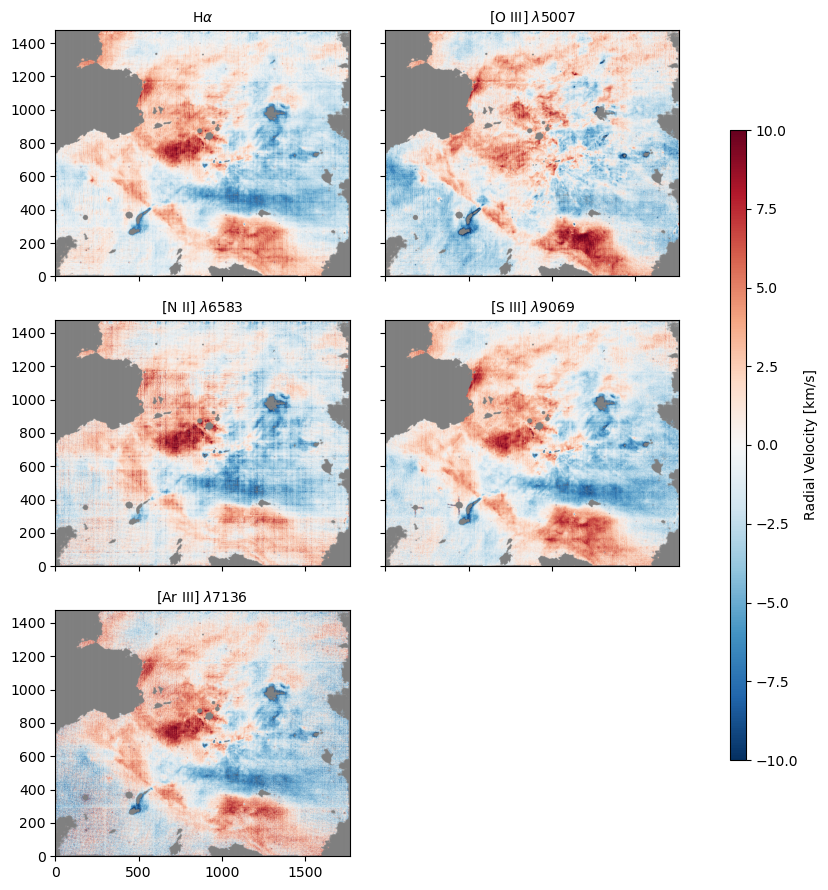

In [8]:
# Layout setup
n_plots = len(data_all)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

# Loop through datasets
im = None
for ax, name in zip(axes, data_all):
    vv = raw_data[name]["vv"] - np.nanmean(raw_data[name]["vv"])

    im = ax.imshow(vv, cmap='RdBu_r', origin='lower', vmin=-10, vmax=10)
    ax.set_title(labels_dict.get(name, name), fontsize=10)
    
    # Set black background for NaNs
    im.cmap.set_bad(color='gray')
#    ax.invert_yaxis()


# Remove unused axes
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

# Add colorbar in a manually defined axis (position = [left, bottom, width, height])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # adjust as needed
fig.colorbar(im, cax=cbar_ax).set_label("Radial Velocity [km/s]")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for cbar
plt.savefig("Imgs/velocity_maps_shared_cbar_fixed.pdf", bbox_inches='tight')
plt.show()